In [2]:
%matplotlib inline
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import numpy as np
import matplotlib.pyplot as plt
import os
print('Using PyTorch version:', torch.__version__)
if torch.cuda.is_available():
  print('Using GPU, device name:', torch.cuda.get_device_name(0))
  device = torch.device('cuda')
else:
  print('No GPU found, using CPU instead.')
  device = torch.device('cpu')

Using PyTorch version: 2.11.0+cpu
No GPU found, using CPU instead.


In [3]:
batch_size = 32
data_dir = './data'
# Check if the data directory exists; if not, create it
if not os.path.exists(data_dir):
  os.makedirs(data_dir)
  print("Created the data/ directory")
else:
  print("The data/ directory already exists")

print("data_dir =", data_dir)
train_dataset = datasets.MNIST(data_dir, train=True, download=True,transform=ToTensor())
test_dataset = datasets.MNIST(data_dir, train=False, transform=ToTensor())
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

Created the data/ directory
data_dir = ./data


100%|██████████| 9.91M/9.91M [00:00<00:00, 30.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.04MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.94MB/s]


In [4]:
for (data, target) in train_loader:
  print('data:', data.size(), 'type:', data.type())
  print('target:', target.size(), 'type:', target.type())
  break

data: torch.Size([32, 1, 28, 28]) type: torch.FloatTensor
target: torch.Size([32]) type: torch.LongTensor


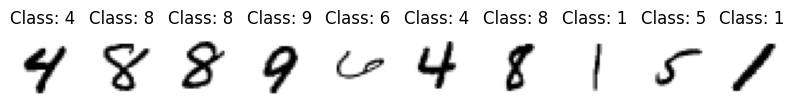

In [5]:
pltsize=1
plt.figure(figsize=(10*pltsize, pltsize))
for i in range(10):
  plt.subplot(1,10,i+1)
  plt.axis('off')
  plt.imshow(data[i,:,:,:].numpy().reshape(28,28), cmap="gray_r")
  plt.title('Class: '+str(target[i].item()))


In [16]:
class SimpleMLP(nn.Module):
  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
nn.Flatten(),
nn.Linear(28*28, 20),
nn.ReLU(),
nn.Linear(20, 10)
)
  def forward(self, x):
    return self.layers(x)

model = SimpleMLP().to(device)
print(model)

SimpleMLP(
  (layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=20, bias=True)
    (2): ReLU()
    (3): Linear(in_features=20, out_features=10, bias=True)
  )
)


In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())

In [8]:
def correct(output, target):
  predicted_digits = output.argmax(1) # pick digit with largest network output
  correct_ones = (predicted_digits == target).type(torch.float) # 1.0 for correct, 0.0 for incorrect
  return correct_ones.sum().item() # count number of correct ones

In [10]:
def train(data_loader, model, criterion, optimizer):
  model.train()

  num_batches = len(data_loader)
  num_items = len(data_loader.dataset)
  total_loss = 0
  total_correct = 0
  for data, target in data_loader:
    # Copy data and targets to GPU
    data = data.to(device)
    target = target.to(device)
    # Do a forward pass
    output = model(data)
    # Calculate the loss
    loss = criterion(output, target)
    total_loss += loss
    # Count number of correct digits
    total_correct += correct(output, target)
    # Backpropagation
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

  train_loss = total_loss/num_batches
  accuracy = total_correct/num_items
  print(f"Average loss: {train_loss:7f}, accuracy: {accuracy:.2%}")

In [17]:
%%time
epochs = 10
for epoch in range(epochs):
  print(f"Training epoch: {epoch+1}")
  train(train_loader, model, criterion, optimizer)

Training epoch: 1
Average loss: 2.306336, accuracy: 11.06%
Training epoch: 2
Average loss: 2.306336, accuracy: 11.06%
Training epoch: 3
Average loss: 2.306338, accuracy: 11.06%
Training epoch: 4
Average loss: 2.306336, accuracy: 11.06%
Training epoch: 5
Average loss: 2.306337, accuracy: 11.06%
Training epoch: 6
Average loss: 2.306338, accuracy: 11.06%
Training epoch: 7
Average loss: 2.306338, accuracy: 11.06%
Training epoch: 8
Average loss: 2.306336, accuracy: 11.06%
Training epoch: 9
Average loss: 2.306337, accuracy: 11.06%
Training epoch: 10
Average loss: 2.306337, accuracy: 11.06%
CPU times: user 1min 24s, sys: 58.1 ms, total: 1min 24s
Wall time: 1min 26s


In [14]:
def test(test_loader, model, criterion):
  model.eval()
  num_batches = len(test_loader)
  num_items = len(test_loader.dataset)
  test_loss = 0
  total_correct = 0
  with torch.no_grad():
    for data, target in test_loader:
# Copy data and targets to GPU
      data = data.to(device)
      target = target.to(device)
# Do a forward pass
      output = model(data)
# Calculate the loss
      loss = criterion(output, target)
      test_loss += loss.item()
# Count number of correct digits
      total_correct += correct(output, target)
  test_loss = test_loss/num_batches
  accuracy = total_correct/num_items
  print(f"Testset accuracy: {100*accuracy:>0.1f}%, average loss: {test_loss:>7f}")


In [18]:
test(test_loader, model, criterion)

Testset accuracy: 10.8%, average loss: 2.306965


### 2.3 Bài tập 1: Mô hình với hai lớp tuyến tính (Model with two linear layers)

Dưới đây là định nghĩa của mô hình phức tạp hơn (`ComplexMLP`) sử dụng:
- 2 lớp tuyến tính (mỗi lớp 50 neurons)
- Hàm kích hoạt ReLU
- Lớp Dropout với tỷ lệ 0.2 sau mỗi lớp ẩn.

In [19]:
class ComplexMLP(nn.Module):
  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
      nn.Flatten(),

      # Lớp ẩn thứ nhất
      nn.Linear(28*28, 50),
      nn.ReLU(),
      nn.Dropout(p=0.2),

      # Lớp ẩn thứ hai
      nn.Linear(50, 50),
      nn.ReLU(),
      nn.Dropout(p=0.2),

      # Lớp đầu ra
      nn.Linear(50, 10)
    )

  def forward(self, x):
    return self.layers(x)

# Khởi tạo mô hình mới
model_complex = ComplexMLP().to(device)
print(model_complex)

ComplexMLP(
  (layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=50, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=50, out_features=50, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.2, inplace=False)
    (7): Linear(in_features=50, out_features=10, bias=True)
  )
)


In [20]:
# Định nghĩa optimizer mới cho mô hình mới
optimizer_complex = torch.optim.Adam(model_complex.parameters())

# Huấn luyện mô hình trong 10 epochs
epochs = 10
for epoch in range(epochs):
  print(f"Training epoch: {epoch+1}")
  train(train_loader, model_complex, criterion, optimizer_complex)

Training epoch: 1
Average loss: 0.474291, accuracy: 85.48%
Training epoch: 2
Average loss: 0.242786, accuracy: 92.77%
Training epoch: 3
Average loss: 0.203231, accuracy: 93.95%
Training epoch: 4
Average loss: 0.179653, accuracy: 94.55%
Training epoch: 5
Average loss: 0.164207, accuracy: 95.06%
Training epoch: 6
Average loss: 0.155777, accuracy: 95.22%
Training epoch: 7
Average loss: 0.149542, accuracy: 95.42%
Training epoch: 8
Average loss: 0.138329, accuracy: 95.81%
Training epoch: 9
Average loss: 0.137015, accuracy: 95.76%
Training epoch: 10
Average loss: 0.134444, accuracy: 95.85%


In [21]:
# Đánh giá mô hình mới trên tập test
test(test_loader, model_complex, criterion)

Testset accuracy: 97.0%, average loss: 0.099965


## 2.4 Bài tập 2: Fashion-MNIST

Trong bài tập này, chúng ta sẽ sử dụng bộ dữ liệu `FashionMNIST` thay thế cho `MNIST` để huấn luyện và đánh giá cả hai mô hình đã xây dựng ở trên.

In [22]:
# Tải bộ dữ liệu Fashion-MNIST
train_dataset_fashion = datasets.FashionMNIST(data_dir, train=True, download=True, transform=ToTensor())
test_dataset_fashion = datasets.FashionMNIST(data_dir, train=False, transform=ToTensor())

train_loader_fashion = DataLoader(dataset=train_dataset_fashion, batch_size=batch_size, shuffle=True)
test_loader_fashion = DataLoader(dataset=test_dataset_fashion, batch_size=batch_size, shuffle=False)

# Nhãn lớp của Fashion-MNIST
fashion_labels = {
    0: 'T-shirt/top',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle boot'
}

100%|██████████| 26.4M/26.4M [00:01<00:00, 17.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 274kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.01MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.1MB/s]


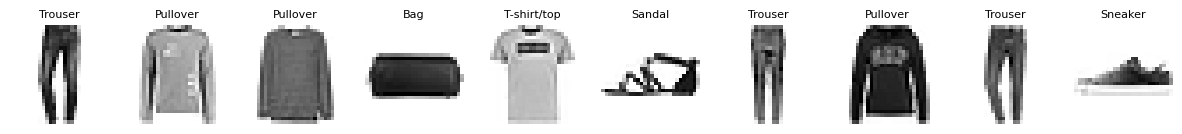

In [23]:
# Trực quan hóa một số ảnh từ Fashion-MNIST
for (data_fashion, target_fashion) in train_loader_fashion:
  break

pltsize = 1.5
plt.figure(figsize=(10*pltsize, pltsize))
for i in range(10):
  plt.subplot(1, 10, i+1)
  plt.axis('off')
  plt.imshow(data_fashion[i, :, :, :].numpy().reshape(28, 28), cmap="gray_r")
  plt.title(fashion_labels[target_fashion[i].item()], fontsize=8)

### Thử nghiệm 1: Huấn luyện SimpleMLP trên Fashion-MNIST

In [24]:
# Khởi tạo lại SimpleMLP cho Fashion-MNIST
model_simple_fashion = SimpleMLP().to(device)
criterion_fashion = nn.CrossEntropyLoss()
optimizer_simple_fashion = torch.optim.Adam(model_simple_fashion.parameters())

# Huấn luyện trong 10 epochs
epochs = 10
for epoch in range(epochs):
  print(f"Training epoch: {epoch+1}")
  train(train_loader_fashion, model_simple_fashion, criterion_fashion, optimizer_simple_fashion)

# Đánh giá trên tập test
test(test_loader_fashion, model_simple_fashion, criterion_fashion)

Training epoch: 1
Average loss: 0.610297, accuracy: 79.32%
Training epoch: 2
Average loss: 0.443460, accuracy: 84.66%
Training epoch: 3
Average loss: 0.411475, accuracy: 85.76%
Training epoch: 4
Average loss: 0.388482, accuracy: 86.31%
Training epoch: 5
Average loss: 0.374605, accuracy: 86.80%
Training epoch: 6
Average loss: 0.362734, accuracy: 87.29%
Training epoch: 7
Average loss: 0.354928, accuracy: 87.38%
Training epoch: 8
Average loss: 0.346539, accuracy: 87.69%
Training epoch: 9
Average loss: 0.340134, accuracy: 87.92%
Training epoch: 10
Average loss: 0.334952, accuracy: 88.06%
Testset accuracy: 85.9%, average loss: 0.395856


### Thử nghiệm 2: Huấn luyện ComplexMLP trên Fashion-MNIST

In [25]:
# Khởi tạo lại ComplexMLP cho Fashion-MNIST
model_complex_fashion = ComplexMLP().to(device)
optimizer_complex_fashion = torch.optim.Adam(model_complex_fashion.parameters())

# Huấn luyện trong 10 epochs
for epoch in range(epochs):
  print(f"Training epoch: {epoch+1}")
  train(train_loader_fashion, model_complex_fashion, criterion_fashion, optimizer_complex_fashion)

# Đánh giá trên tập test
test(test_loader_fashion, model_complex_fashion, criterion_fashion)

Training epoch: 1
Average loss: 0.678207, accuracy: 75.62%
Training epoch: 2
Average loss: 0.482053, accuracy: 82.71%
Training epoch: 3
Average loss: 0.442384, accuracy: 84.30%
Training epoch: 4
Average loss: 0.423470, accuracy: 84.96%
Training epoch: 5
Average loss: 0.408604, accuracy: 85.32%
Training epoch: 6
Average loss: 0.398720, accuracy: 85.47%
Training epoch: 7
Average loss: 0.387732, accuracy: 85.95%
Training epoch: 8
Average loss: 0.383030, accuracy: 86.13%
Training epoch: 9
Average loss: 0.378819, accuracy: 86.23%
Training epoch: 10
Average loss: 0.370822, accuracy: 86.38%
Testset accuracy: 86.7%, average loss: 0.372130
